In [1]:
from experiments.dj.posterior_tables import SBVGPConfig
from experiments.dj.sysident_tables import SIConfig
from experiments.dj.result_tables import (
    SBVGPResult2,
    SIResult,
    FlowPriorResult,
    SBVGPAdaptedResult,
    FPSamplesConfig,
    FPSamples,
    AdaptPriorResult,
)
from experiments.dj.dataloader_tables import DataLoaderConfig


from task_transfer.utils.insilico_stimuli import generate_gabors
from task_transfer.ml_lib.data_loading import build_dataloaders

from task_transfer.evaluation.evaluate_generative_model import compute_logl

import torch
import matplotlib.pyplot as plt
import seaborn as sns


torch.manual_seed(42)

[2024-08-27 13:39:51,147][INFO]: Connecting sshrinivasan@134.76.19.44:3306
[2024-08-27 13:39:51,155][INFO]: Connected sshrinivasan@134.76.19.44:3306
/usr/local/lib/python3.8/dist-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")


In [2]:
DataLoaderConfig()

id,data_fname,train_prop,val_prop
05977a317062b759857ee411a2e60648,/src/project/data/synthetic/haefner_2afc/haefner_2neuron_task1.pkl,0.7,0.2
260a5ea8175f75eaef132f42873ad14a,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl,0.7,0.2
4477b5e82704db0bc19727864c7ef5aa,/src/project/data/synthetic/haefner_2afc/haefner_4neuron_task1.pkl,0.7,0.2
5352c4a57ef18797b082283de593157b,/src/project/data/synthetic/haefner_2afc/haefner_model_4neuron_highdelta_task2_dataset.pkl,0.7,0.2
8e9be142eedb21007255e89dbff362da,/src/project/data/synthetic/haefner_2afc/haefner_model_2neuron_highdelta_task1_dataset.pkl,0.7,0.2
94efb58694007205fac996d7963f88c5,/src/project/data/synthetic/haefner_2afc/haefner_model_1neuron_highdelta_task2_dataset.pkl,0.7,0.2
b8379e7d6998fc94a08a9a3742eec12d,/src/project/data/synthetic/haefner_2afc/flat_haefner_dataset.pkl,0.7,0.2
bb9bdd1ccd59e5a8c801d7f2d43e0317,/src/project/data/synthetic/haefner_2afc/haefner_model_4neuron_highdelta_task1_dataset.pkl,0.7,0.2
d74090584b0b974c4444a5ec64c3d87d,/src/project/data/synthetic/haefner_2afc/haefner_model_2neuron_highdelta_task2_dataset.pkl,0.7,0.2
f1ae78885d2ace1ba976199d4cf1a4d6,/src/project/data/synthetic/haefner_2afc/haefner_model_1neuron_task1_dataset.pkl,0.7,0.2


In [3]:
dl1_id = "8e9be142eedb21007255e89dbff362da"
metric = "val_ll_mean"
limit = 1
download_path = "/tmp"

si_restriction1 = f"dl_id = '{dl1_id}'"
si1 = (SIResult & si_restriction1).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction1 = f"dl_id = '{dl1_id}'"
sbv_restriction1_50k = sbv_restriction1 + " and n_samples = 50000"
sbv1_50k = (SBVGPResult2 & sbv_restriction1_50k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction1_30k = sbv_restriction1 + " and n_samples = 30000"
sbv1_30k = (SBVGPResult2 & sbv_restriction1_30k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction1_20k = sbv_restriction1 + " and n_samples = 20000"
sbv1_20k = (SBVGPResult2 & sbv_restriction1_20k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction1_10k = sbv_restriction1 + " and n_samples = 10000"
sbv1_10k = (SBVGPResult2 & sbv_restriction1_10k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

si1_model = torch.load(si1["model"], map_location="cpu")
sbv1_50k_model = torch.load(sbv1_50k["model"], map_location="cpu")
sbv1_30k_model = torch.load(sbv1_30k["model"], map_location="cpu")
sbv1_20k_model = torch.load(sbv1_20k["model"], map_location="cpu")
sbv1_10k_model = torch.load(sbv1_10k["model"], map_location="cpu")

In [4]:
dl2_id = "d74090584b0b974c4444a5ec64c3d87d"
si_restriction2 = f"dl_id = '{dl2_id}'"

si2 = (SIResult & si_restriction2).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction2 = f"alt_dl_id = '{dl2_id}'"
sbv_restriction2_50k = sbv_restriction2 + " and n_samples = 50000"
sbv2_50k = (SBVGPAdaptedResult & sbv_restriction2_50k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction2_30k = sbv_restriction2 + " and n_samples = 30000"
sbv2_30k = (SBVGPAdaptedResult & sbv_restriction2_30k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction2_20k = sbv_restriction2 + " and n_samples = 20000"
sbv2_20k = (SBVGPAdaptedResult & sbv_restriction2_20k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction2_10k = sbv_restriction2 + " and n_samples = 10000"
sbv2_10k = (SBVGPAdaptedResult & sbv_restriction2_10k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

si2_model = torch.load(si2["model"], map_location="cpu")
sbv2_50k_model = torch.load(sbv2_50k["model"], map_location="cpu")
sbv2_30k_model = torch.load(sbv2_30k["model"], map_location="cpu")
sbv2_20k_model = torch.load(sbv2_20k["model"], map_location="cpu")
sbv2_10k_model = torch.load(sbv2_10k["model"], map_location="cpu")

In [5]:
dataloader_config1 = {
    "data_fname": "/src/project/data/synthetic/haefner_2afc/haefner_model_2neuron_highdelta_task1_dataset.pkl",
    "train_prop": 0.7,
    "val_prop": 0.2,
    "batch_size": 128,
}
train_loader1, val_loader1, test_loader1 = build_dataloaders(
    data_fname=dataloader_config1["data_fname"],
    train_prop=dataloader_config1["train_prop"],
    val_prop=dataloader_config1["val_prop"],
    batch_size=dataloader_config1["batch_size"],
)

dataloader_config2 = {
    "data_fname": "/src/project/data/synthetic/haefner_2afc/haefner_model_2neuron_highdelta_task2_dataset.pkl",
    "train_prop": 0.7,
    "val_prop": 0.2,
    "batch_size": 128,
}
train_loader2, val_loader2, test_loader2 = build_dataloaders(
    data_fname=dataloader_config2["data_fname"],
    train_prop=dataloader_config2["train_prop"],
    val_prop=dataloader_config2["val_prop"],
    batch_size=dataloader_config2["batch_size"],
)

In [6]:
data_dim = 0
cond_dim = 1
reduction = "mean"
uncertainty = "none"
normalize = "none"
unit = "bits"

evaluate_pred_model = lambda model, data_loader: compute_logl(
    model,
    data_loader,
    data_dim=data_dim,
    cond_dim=cond_dim,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

In [7]:
train_si1_data1 = evaluate_pred_model(si1_model, train_loader1)[0]
val_si1_data1 = evaluate_pred_model(si1_model, val_loader1)[0]
test_si1_data1 = evaluate_pred_model(si1_model, test_loader1)[0]

train_sbv1_50k_data1 = evaluate_pred_model(sbv1_50k_model, train_loader1)[0]
val_sbv1_50k_data1 = evaluate_pred_model(sbv1_50k_model, val_loader1)[0]
test_sbv1_50k_data1 = evaluate_pred_model(sbv1_50k_model, test_loader1)[0]

train_sbv1_30k_data1 = evaluate_pred_model(sbv1_30k_model, train_loader1)[0]
val_sbv1_30k_data1 = evaluate_pred_model(sbv1_30k_model, val_loader1)[0]
test_sbv1_30k_data1 = evaluate_pred_model(sbv1_30k_model, test_loader1)[0]

train_sbv1_20k_data1 = evaluate_pred_model(sbv1_20k_model, train_loader1)[0]
val_sbv1_20k_data1 = evaluate_pred_model(sbv1_20k_model, val_loader1)[0]
test_sbv1_20k_data1 = evaluate_pred_model(sbv1_20k_model, test_loader1)[0]

train_sbv1_10k_data1 = evaluate_pred_model(sbv1_10k_model, train_loader1)[0]
val_sbv1_10k_data1 = evaluate_pred_model(sbv1_10k_model, val_loader1)[0]
test_sbv1_10k_data1 = evaluate_pred_model(sbv1_10k_model, test_loader1)[0]

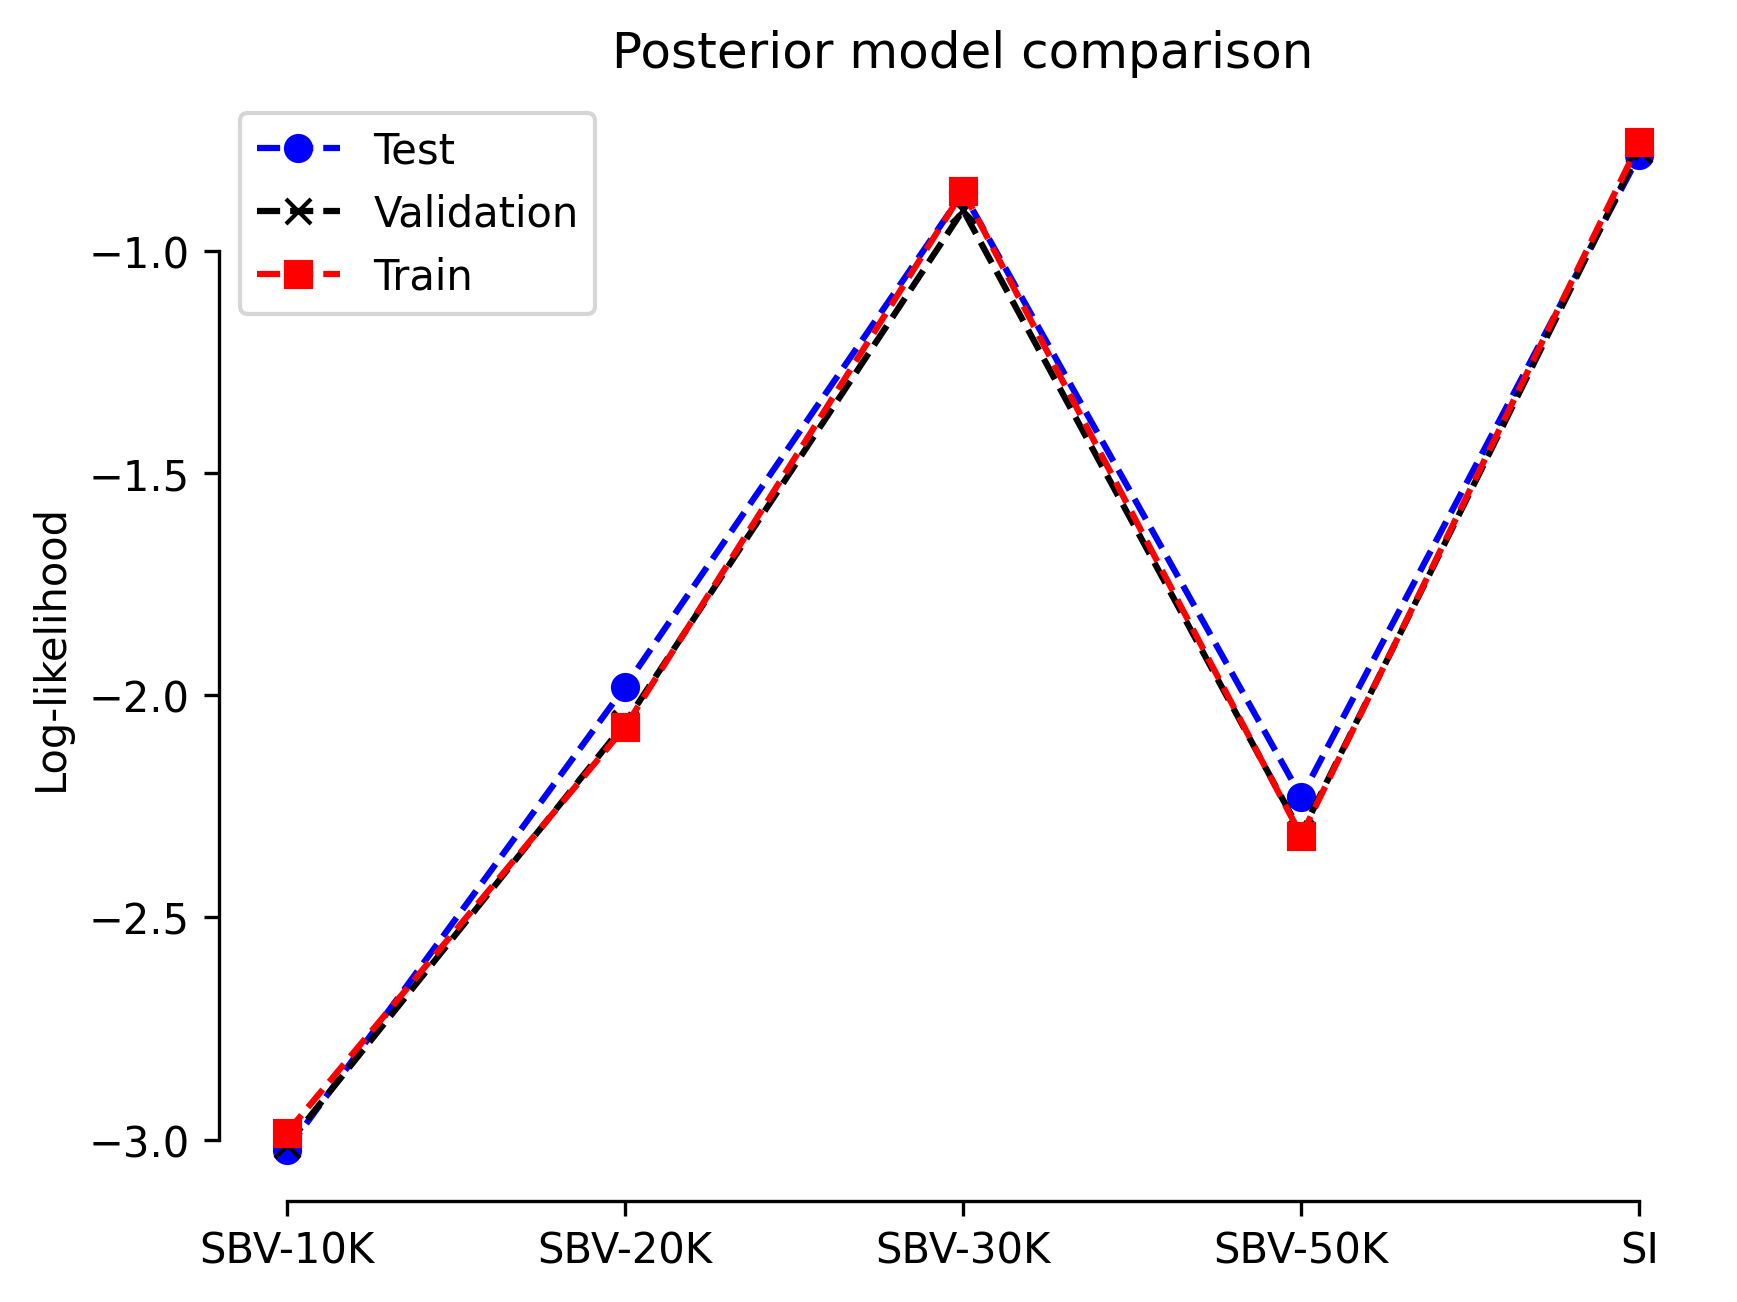

In [8]:
train_metrics_data1 = [
    train_si1_data1,
    train_sbv1_50k_data1,
    train_sbv1_30k_data1,
    train_sbv1_20k_data1,
    train_sbv1_10k_data1,
]
val_metrics_data1 = [
    val_si1_data1,
    val_sbv1_50k_data1,
    val_sbv1_30k_data1,
    val_sbv1_20k_data1,
    val_sbv1_10k_data1,
]
test_metrics_data1 = [
    test_si1_data1,
    test_sbv1_50k_data1,
    test_sbv1_30k_data1,
    test_sbv1_20k_data1,
    test_sbv1_10k_data1,
]

# Update the x-axis labels
x = ["SI", "SBV-50K", "SBV-30K", "SBV-20K", "SBV-10K"]

# Plot the test log-likelihoods with updated models
fig, ax = plt.subplots(dpi=300)
ax.plot(
    x[::-1], test_metrics_data1[::-1], color="blue", marker="o", linestyle="--", label="Test"
)
ax.plot(
    x[::-1],
    val_metrics_data1[::-1],
    color="black",
    marker="x",
    linestyle="--",
    label="Validation",
)
ax.plot(
    x[::-1], train_metrics_data1[::-1], color="red", marker="s", linestyle="--", label="Train"
)

sns.despine(ax=ax, trim=True)
ax.set_ylabel("Log-likelihood")
ax.set_title("Posterior model comparison")
ax.legend()
plt.show()

In [9]:
train_si2_data2 = evaluate_pred_model(si2_model, train_loader2)[0]
val_si2_data2 = evaluate_pred_model(si2_model, val_loader2)[0]
test_si2_data2 = evaluate_pred_model(si2_model, test_loader2)[0]

train_sbv2_50k_data2 = evaluate_pred_model(sbv2_50k_model, train_loader2)[0]
val_sbv2_50k_data2 = evaluate_pred_model(sbv2_50k_model, val_loader2)[0]
test_sbv2_50k_data2 = evaluate_pred_model(sbv2_50k_model, test_loader2)[0]

train_sbv2_30k_data2 = evaluate_pred_model(sbv2_50k_model, train_loader2)[0]
val_sbv2_50k_data2 = evaluate_pred_model(sbv2_50k_model, val_loader2)[0]
test_sbv2_50k_data2 = evaluate_pred_model(sbv2_50k_model, test_loader2)[0]

train_sbv2_30k_data2 = evaluate_pred_model(sbv2_30k_model, train_loader2)[0]
val_sbv2_30k_data2 = evaluate_pred_model(sbv2_30k_model, val_loader2)[0]
test_sbv2_30k_data2 = evaluate_pred_model(sbv2_30k_model, test_loader2)[0]

train_sbv2_20k_data2 = evaluate_pred_model(sbv2_20k_model, train_loader2)[0]
val_sbv2_20k_data2 = evaluate_pred_model(sbv2_20k_model, val_loader2)[0]
test_sbv2_20k_data2 = evaluate_pred_model(sbv2_20k_model, test_loader2)[0]

train_sbv2_10k_data2 = evaluate_pred_model(sbv2_10k_model, train_loader2)[0]
val_sbv2_10k_data2 = evaluate_pred_model(sbv2_10k_model, val_loader2)[0]
test_sbv2_10k_data2 = evaluate_pred_model(sbv2_10k_model, test_loader2)[0]

train_si1_data2 = evaluate_pred_model(si1_model, train_loader2)[0]
val_si1_data2 = evaluate_pred_model(si1_model, val_loader2)[0]
test_si1_data2 = evaluate_pred_model(si1_model, test_loader2)[0]

train_sbv1_50k_data2 = evaluate_pred_model(sbv1_50k_model, train_loader2)[0]
val_sbv1_50k_data2 = evaluate_pred_model(sbv1_50k_model, val_loader2)[0]
test_sbv1_50k_data2 = evaluate_pred_model(sbv1_50k_model, test_loader2)[0]

train_sbv1_30k_data2 = evaluate_pred_model(sbv1_30k_model, train_loader2)[0]
val_sbv1_30k_data2 = evaluate_pred_model(sbv1_30k_model, val_loader2)[0]
test_sbv1_30k_data2 = evaluate_pred_model(sbv1_30k_model, test_loader2)[0]

train_sbv1_20k_data2 = evaluate_pred_model(sbv1_20k_model, train_loader2)[0]
val_sbv1_20k_data2 = evaluate_pred_model(sbv1_20k_model, val_loader2)[0]
test_sbv1_20k_data2 = evaluate_pred_model(sbv1_20k_model, test_loader2)[0]

train_sbv1_10k_data2 = evaluate_pred_model(sbv1_10k_model, train_loader2)[0]
val_sbv1_10k_data2 = evaluate_pred_model(sbv1_10k_model, val_loader2)[0]
test_sbv1_10k_data2 = evaluate_pred_model(sbv1_10k_model, test_loader2)[0]


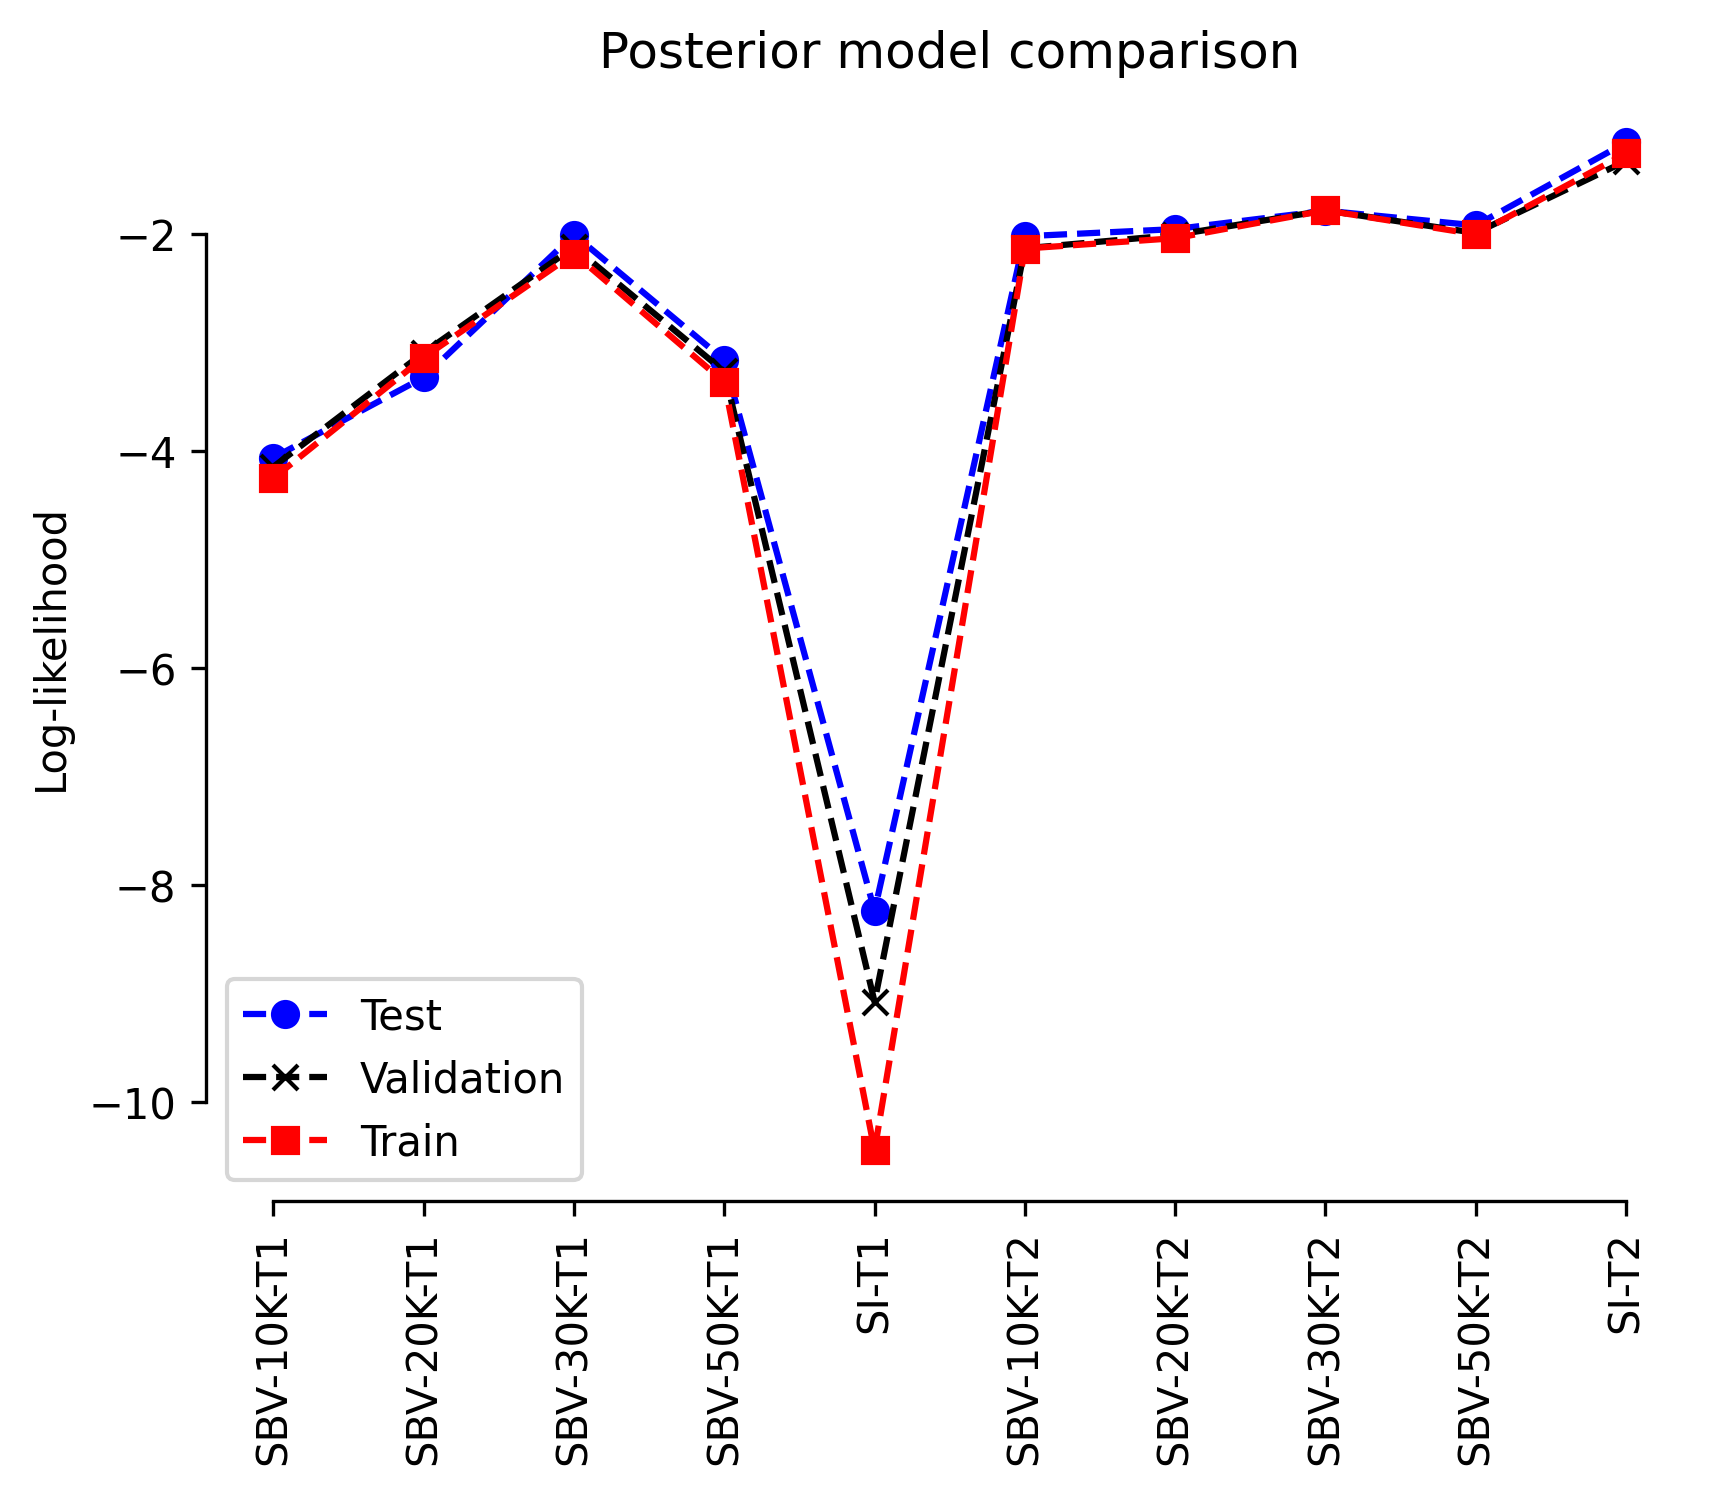

In [10]:
train_metrics_data2 = [
    train_si2_data2,
    train_sbv2_50k_data2,
    train_sbv2_30k_data2,
    train_sbv2_20k_data2,
    train_sbv2_10k_data2,
    train_si1_data2,
    train_sbv1_50k_data2,
    train_sbv1_30k_data2,
    train_sbv1_20k_data2,
    train_sbv1_10k_data2,
]

val_metrics_data2 = [
    val_si2_data2,
    val_sbv2_50k_data2,
    val_sbv2_30k_data2,
    val_sbv2_20k_data2,
    val_sbv2_10k_data2,
    val_si1_data2,
    val_sbv1_50k_data2,
    val_sbv1_30k_data2,
    val_sbv1_20k_data2,
    val_sbv1_10k_data2,
]

test_metrics_data2 = [
    test_si2_data2,
    test_sbv2_50k_data2,
    test_sbv2_30k_data2,
    test_sbv2_20k_data2,
    test_sbv2_10k_data2,
    test_si1_data2,
    test_sbv1_50k_data2,
    test_sbv1_30k_data2,
    test_sbv1_20k_data2,
    test_sbv1_10k_data2,
]

# Update the x-axis labels
x = [
    "SI-T2",
    "SBV-50K-T2",
    "SBV-30K-T2",
    "SBV-20K-T2",
    "SBV-10K-T2",
    "SI-T1",
    "SBV-50K-T1",
    "SBV-30K-T1",
    "SBV-20K-T1",
    "SBV-10K-T1",
]

# Plot the test log-likelihoods with updated models
fig, ax = plt.subplots(dpi=300)
ax.plot(
    x[::-1], test_metrics_data2[::-1], color="blue", marker="o", linestyle="--", label="Test",
)
ax.plot(
    x[::-1],
    val_metrics_data2[::-1],
    color="black",
    marker="x",
    linestyle="--",
    label="Validation",
)
ax.plot(
    x[::-1], train_metrics_data2[::-1], color="red", marker="s", linestyle="--", label="Train",
)
sns.despine(ax=ax, trim=True)
# rotate the x-axis labels
plt.xticks(rotation=90)
ax.set_ylabel("Log-likelihood")
ax.set_title("Posterior model comparison")
ax.legend()
plt.show()

In [11]:
from experiments.orientation_discrimination.haefner_model.configs import haefner_model_2neuron_highdelta_task1 as cfg

In [13]:
from task_transfer.utils.model_utils import build_haefner_model

In [14]:
haefner_model = build_haefner_model(
    p_c=cfg['p_c'],
    c1_psi=cfg['c1_psi'],
    c2_psi=cfg['c2_psi'],
    kappa=cfg['kappa'],
    g_phi=cfg['g_phi'],
    delta=cfg['delta'],
    lam=cfg['lam'],
    x_phi=cfg['x_phi'],
    obs_sigma=cfg['obs_sigma'],
    obs_h=cfg['obs_h'],
    obs_w=cfg['obs_w'],
)

In [25]:
train_r1 = torch.cat([r for r, _ in train_loader1], dim=0)
train_r2 = torch.cat([r for r, _ in train_loader2], dim=0)
print(train_r1.shape)
print(train_r2.shape)

torch.Size([7000, 2])
torch.Size([7000, 2])


(0.0, 6.0)

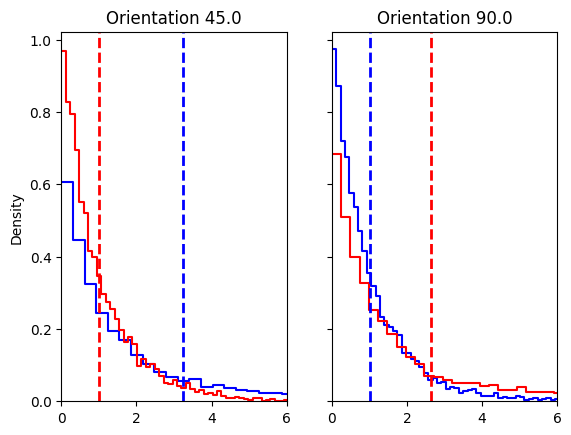

In [44]:
fig, axs = plt.subplots(1, 2, dpi=100, sharey=True)
stat = "density"
element = "step"
sns.histplot(train_r1[:, 0], ax=axs[0], stat=stat, element=element, color="blue", label="Task 1", fill=False)
sns.histplot(train_r2[:, 0], ax=axs[0], stat=stat, element=element, color="red", label="Task 2", fill=False)
sns.histplot(train_r1[:, 1], ax=axs[1], stat=stat, element=element, color="blue", label="Task 1", fill=False)
sns.histplot(train_r2[:, 1], ax=axs[1], stat=stat, element=element, color="red", label="Task 2", fill=False)
# draw a vertical line at mean of the data
axs[0].axvline(train_r1[:, 0].mean(), color='blue', linestyle='dashed', linewidth=2)
axs[0].axvline(train_r2[:, 0].mean(), color='red', linestyle='dashed', linewidth=2)
axs[1].axvline(train_r1[:, 1].mean(), color='blue', linestyle='dashed', linewidth=2)
axs[1].axvline(train_r2[:, 1].mean(), color='red', linestyle='dashed', linewidth=2)
axs[0].set_title(f"Orientation {haefner_model.x_phi[0] * 180 / torch.pi}")
axs[1].set_title(f"Orientation {haefner_model.x_phi[1] * 180 / torch.pi}")
axs[0].set_xlim(0, 6)
# axs[0].set_ylim(0, 6)
axs[1].set_xlim(0, 6)

In [50]:
best_sbv1_model = sbv1_30k_model
best_sbv2_model = sbv2_30k_model

In [68]:
# orientations = torch.tensor([0.0])
orientations = torch.tensor([0.0, torch.pi/4, torch.pi/3, torch.pi/2, 2*torch.pi/3, 3*torch.pi/4])
obs_h, obs_w = 12, 12
gabor_params = dict(
    {
        "canvas_size": [obs_h, obs_w],
        "sizes": [10],
        "spatial_frequencies": [1 / 3],
        "contrasts": [1.0],
        "grey_levels": [0.0],
        "eccentricities": [0.0],
        "locations": [[6, 6]],
        "phases": [torch.pi / 2],
        "relative_sf": False,
    },
)
stimuli = torch.Tensor(
    generate_gabors(orientations=orientations.tolist(), gabor_params=gabor_params)
)

In [69]:
haefner_model.x_phi

tensor([0.7854, 1.5708])

In [70]:
orientations

tensor([0.0000, 0.7854, 1.0472, 1.5708, 2.0944, 2.3562])

In [72]:
get_density = lambda model, stimulus, x: model.trainable_distribution.distribution(
    cond=stimulus.reshape(-1, cfg["obs_h"] * cfg["obs_w"])
).log_prob(x).exp()

In [73]:
zero = torch.finfo(torch.float32).eps
x = torch.linspace(zero, 6, steps=1000).unsqueeze(-1)
si1_pdfs = []
si2_pdfs = []
sbv1_pdfs = []
sbv2_pdfs = []
for stimulus in stimuli:
    with torch.no_grad():
        si1_pdfs.append(get_density(si1_model, stimulus, x))
        si2_pdfs.append(get_density(si2_model, stimulus, x))
        sbv1_pdfs.append(get_density(best_sbv1_model, stimulus, x))
        sbv2_pdfs.append(get_density(best_sbv2_model, stimulus, x))
si1_pdfs = torch.stack(si1_pdfs, dim=0)
si2_pdfs = torch.stack(si2_pdfs, dim=0)
sbv1_pdfs = torch.stack(sbv1_pdfs, dim=0)
sbv2_pdfs = torch.stack(sbv2_pdfs, dim=0)

In [74]:
si1_pdfs.shapes

torch.Size([6, 1000])

(0.0, 3.0)

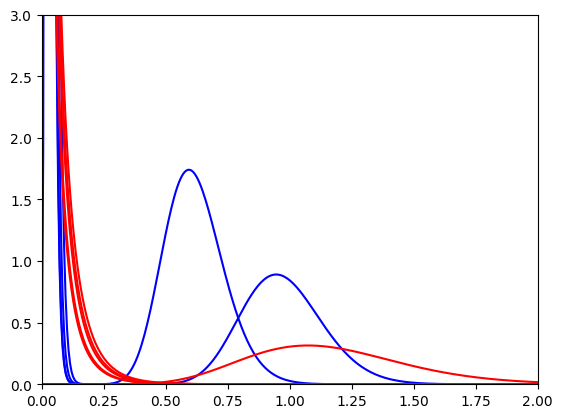

In [81]:
plt.plot(x, sbv1_pdfs.T, color="blue")
plt.plot(x, sbv2_pdfs.T, color="red")
plt.xlim(0, 2)
plt.ylim(0, 3)

(0.0, 5.0)

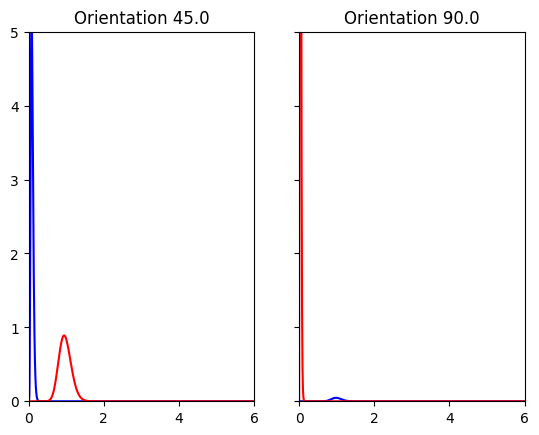

In [56]:
fig, axs = plt.subplots(1, 2, dpi=100, sharey=True)
stat = "density"
element = "step"

axs[0].plot(x, si1_data1_pdfs[0], color="blue", label="SI")
axs[0].plot(x, sbv1_data1_pdfs[0], color="red", label="SBV")
axs[1].plot(x, si1_data1_pdfs[1], color="blue", label="SI")
axs[1].plot(x, sbv1_data1_pdfs[1], color="red", label="SBV")

# # draw a vertical line at mean of the data
# axs[0].axvline(train_r1[:, 0].mean(), color="blue", linestyle="dashed", linewidth=2)
# axs[0].axvline(train_r2[:, 0].mean(), color="red", linestyle="dashed", linewidth=2)
# axs[1].axvline(train_r1[:, 1].mean(), color="blue", linestyle="dashed", linewidth=2)
# axs[1].axvline(train_r2[:, 1].mean(), color="red", linestyle="dashed", linewidth=2)
axs[0].set_title(f"Orientation {haefner_model.x_phi[0] * 180 / torch.pi}")
axs[1].set_title(f"Orientation {haefner_model.x_phi[1] * 180 / torch.pi}")
axs[0].set_xlim(0, 6)
axs[0].set_ylim(0, 5)
axs[1].set_xlim(0, 6)
axs[1].set_ylim(0, 5)